# 1. Libraries and Imports

In [16]:
# Basic data processing & visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests and distribution checks
from scipy.stats import shapiro, spearmanr, chi2_contingency

# Data preprocessing & validation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Machine learning models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Performance metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc

# Suppress warnings for a clean notebook
import warnings
warnings.filterwarnings('ignore')

# 2. KDD Workflow: Data Preparation & Statistical Analysis

## 2.1 Loading Data & Checking Values ​​(0 vs. NaN)
A critical step in preprocessing, in accordance with the lecture guidelines, is distinguishing between missing values ​​(`NaN`) and intentional zero values ​​(`0`).
In our dataset, a `0` for the genes represents a biological reality (wild type / no mutation), whereas `1` indicates a mutated gene. We check the dataset for actual missing values ​​(`NaN`).

In [17]:
# Load dataset
df = pd.read_csv("TCGA_InfoWithGrade.csv")

# Explicit check for missing values ​​(NaN)
print("Number of actual missing values ​​(NaN) per column:")
print(df.isna().sum())

# Check target class distribution (class skew)
print("\nDistribution of the target class (Grade):")
print(df['Grade'].value_counts())

Number of actual missing values ​​(NaN) per column:
Grade               0
Gender              0
Age_at_diagnosis    0
Race                0
IDH1                0
TP53                0
ATRX                0
PTEN                0
EGFR                0
CIC                 0
MUC16               0
PIK3CA              0
NF1                 0
PIK3R1              0
FUBP1               0
RB1                 0
NOTCH1              0
BCOR                0
CSMD3               0
SMARCA4             0
GRIN2A              0
IDH2                0
FAT4                0
PDGFRA              0
dtype: int64

Distribution of the target class (Grade):
Grade
0    487
1    352
Name: count, dtype: int64


## 2.2 Checking Statistical Assumptions (Important Hints)
By definition, parametric tests (such as Pearson correlation) require metric, normally distributed data.
Since our mutation data are binary ($0/1$), we use the **Chi-square test of independence ($\chi^2$)**. For age, we test for normal distribution using the **Shapiro-Wilk test**. If the data are not normally distributed, we switch to **Spearman rank correlation**.

In [19]:
# A) Normality test for Age (continuous feature)
stat, p_val_shapiro = shapiro(df['Age_at_diagnosis'])
print(f"Shapiro-Wilk test for Age: p-value = {p_val_shapiro:.4e}")

if p_val_shapiro < 0.05:
    print("-> Age is NOT normally distributed. Using Spearman instead of Pearson correlation.")
    corr_eff, p_val_spearman = spearmanr(df['Age_at_diagnosis'], df['Grade'])
    print(f"Spearman correlation (Age vs. Grade): Coefficient = {corr_eff:.4f}, p-value = {p_val_spearman:.4e}")
else:
    print("-> Age is normally distributed.")

# B) Significance testing for binary/categorical features (Chi-Square Test)
print("\nSignificance testing of binary features using Chi-Square test:")
significant_features = []

for col in df.columns:
    if col not in ['Grade', 'Age_at_diagnosis']:
        contingency_table = pd.crosstab(df[col], df['Grade'])
        chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)
        
        if p_chi2 < 0.05:
            significant_features.append(col)
            print(f" - {col}: Significant association found (p = {p_chi2:.4e})")

if p_val_spearman < 0.05:
    significant_features.append('Age_at_diagnosis')

Shapiro-Wilk test for Age: p-value = 4.6531e-08
-> Age is NOT normally distributed. Using Spearman instead of Pearson correlation.
Spearman correlation (Age vs. Grade): Coefficient = 0.5307, p-value = 3.9441e-62

Significance testing of binary features using Chi-Square test:
 - Race: Significant association found (p = 3.1298e-03)
 - IDH1: Significant association found (p = 7.1297e-93)
 - TP53: Significant association found (p = 3.9269e-06)
 - ATRX: Significant association found (p = 1.6642e-19)
 - PTEN: Significant association found (p = 5.5403e-26)
 - EGFR: Significant association found (p = 5.4588e-12)
 - CIC: Significant association found (p = 3.7346e-18)
 - MUC16: Significant association found (p = 8.0541e-04)
 - NF1: Significant association found (p = 1.5372e-02)
 - PIK3R1: Significant association found (p = 5.0081e-03)
 - FUBP1: Significant association found (p = 3.6529e-07)
 - RB1: Significant association found (p = 4.0428e-08)
 - NOTCH1: Significant association found (p = 2.042

## 2.3 Train-Test Split & Feature Scaling
We split the data into features ($X$) and the target variable ($y$). We use a `StratifiedKFold` split to maintain the same target class distribution in both the training and test sets.

Additionally, we standardize the features using `StandardScaler`. This is essential for distance-based models like **K-NN**, as the "age" feature—due to its higher numerical values—would otherwise dominate the binary gene mutations during the Euclidean distance calculation.

In [20]:
# Separate features and label
X = df[significant_features]
y = df['Grade']

# Stratified split (70% training, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42, stratify=y
)

# Initialize and apply standardization (to avoid data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]} samples")
print(f"Test set size: {X_test_scaled.shape[0]} samples")

Training set size: 587 samples
Test set size: 252 samples


# 3. Modeling: K-Nearest Neighbors (K-NN)
As the first model, we implement a K-NN classifier (a distance-based *lazy learner*). We choose an odd value of $k=5$ to avoid a tie in the majority vote for our binary target class.

Evaluation is performed using metrics suitable for imbalanced data (precision, recall, F1-score) as well as stratified 5-fold cross-validation (`StratifiedKFold`).

In [21]:
# Train K-NN model
knn_model = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_knn = knn_model.predict(X_test_scaled)
y_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("="*60)
print("EVALUATION: K-Nearest Neighbors (K-NN)")
print("="*60)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['LGG (Grade 0)', 'GBM (Grade 1)']))

# Stratified Cross-Validation (metric: F1 score due to class skew)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_cv_scores = cross_val_score(knn_model, scaler.transform(X), y, cv=cv_strategy, scoring='f1')
print(f"K-NN - mean F1 score (5-fold CV): {knn_cv_scores.mean():.4f}")

EVALUATION: K-Nearest Neighbors (K-NN)
Confusion Matrix:
[[125  21]
 [ 17  89]]

Classification Report:
               precision    recall  f1-score   support

LGG (Grade 0)       0.88      0.86      0.87       146
GBM (Grade 1)       0.81      0.84      0.82       106

     accuracy                           0.85       252
    macro avg       0.84      0.85      0.85       252
 weighted avg       0.85      0.85      0.85       252

K-NN - mean F1 score (5-fold CV): 0.8308


# 4. Modeling: Artificial Neural Network (ANN)
As a second model, we employ an artificial neural network (a function-based approach) in the form of a multi-layer perceptron (`MLPClassifier`). We use a single hidden layer with 16 neurons.

Here, too, we perform the same evaluation and stratified cross-validation to ensure direct comparability of generalization performance.

In [22]:
# Train ANN model
ann_model = MLPClassifier(hidden_layer_sizes=(16,), max_iter=500, random_state=42)
ann_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_ann = ann_model.predict(X_test_scaled)
y_proba_ann = ann_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
print("="*60)
print("EVALUATION: Artificial Neural Network (ANN)")
print("="*60)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_ann))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann, target_names=['LGG (Grade 0)', 'GBM (Grade 1)']))

# Stratified Cross-Validation (metric: F1 score due to class skew)
ann_cv_scores = cross_val_score(ann_model, scaler.transform(X), y, cv=cv_strategy, scoring='f1')
print(f"ANN - mean F1 score (5-fold CV): {ann_cv_scores.mean():.4f}")

EVALUATION: Artificial Neural Network (ANN)
Confusion Matrix:
[[125  21]
 [ 16  90]]

Classification Report:
               precision    recall  f1-score   support

LGG (Grade 0)       0.89      0.86      0.87       146
GBM (Grade 1)       0.81      0.85      0.83       106

     accuracy                           0.85       252
    macro avg       0.85      0.85      0.85       252
 weighted avg       0.85      0.85      0.85       252

ANN - mean F1 score (5-fold CV): 0.8418


# 5. Visualization: ROC Curve Comparison
To compare the overall performance and discriminative power of the two models independently of the chosen classification threshold, we plot the ROC curves (Receiver Operating Characteristic) and calculate the area under the curve (AUC).

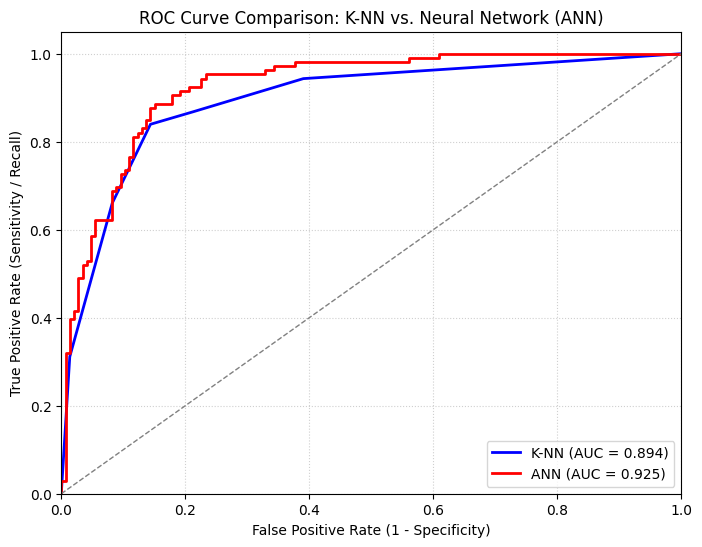

In [23]:
# Calculate ROC values
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

fpr_ann, tpr_ann, _ = roc_curve(y_test, y_proba_ann)
roc_auc_ann = auc(fpr_ann, tpr_ann)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='blue', lw=2, label=f'K-NN (AUC = {roc_auc_knn:.3f})')
plt.plot(fpr_ann, tpr_ann, color='red', lw=2, label=f'ANN (AUC = {roc_auc_ann:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve Comparison: K-NN vs. Neural Network (ANN)')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()